<a href="https://colab.research.google.com/github/jlin219myseneca-art/BAN-WTP/blob/main/Scraping4Pub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook 1 — Target Public Sources (No Anti‑Bot)

In [10]:
PUBLIC_SOURCES = {
    "ontario_government": {
        "base_url": "https://www.gojobs.gov.on.ca",
        "source_type": "government"
    },
    "ibm": {
        "base_url": "https://www.ibm.com/careers",
        "source_type": "career_page"
    },
    "microsoft": {
        "base_url": "https://careers.microsoft.com",
        "source_type": "career_page"
    }
}


Notebook 2 — Polite HTTP Client (Important)

In [11]:
import requests
import time
import random

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (compatible; LaborMarketResearch/1.0; "
        "research-purpose)"
    ),
    "Accept-Language": "en-CA,en;q=0.9"
}

def polite_get(url: str) -> str:
    response = requests.get(url, headers=HEADERS, timeout=30)
    response.raise_for_status()

    # Polite delay
    time.sleep(random.uniform(2, 4))
    return response.text

Notebook 3 — Ontario Government Jobs (Concrete Example)

In [12]:
from bs4 import BeautifulSoup
import re

def extract_text_from_html(html: str) -> str:
    soup = BeautifulSoup(html, "html.parser")

    # Remove scripts/styles
    for tag in soup(["script", "style"]):
        tag.decompose()

    text = soup.get_text(separator=" ")
    text = re.sub(r"\s+", " ", text)
    return text.lower()

Notebook 4 — Certification Extraction (Same Logic, Reused)

In [13]:
CERT_REGEX = {
    "PMP": r"\bpmp\b",
    "ITIL": r"itil",
    "ISO 27001": r"iso\s*27001",
    "CISSP": r"cissp",
    "Security+": r"security\+",
    "AWS Solutions Architect": r"aws.*solutions architect",
    "Azure Administrator": r"azure administrator|az-104",
    "Power BI": r"power\s*bi"
}

def extract_certifications(text: str):
    found = []
    for cert, pattern in CERT_REGEX.items():
        if re.search(pattern, text):
            found.append(cert)
    return found

Notebook 5 — Requirement Level Heuristics (Government‑Friendly)

In [14]:
def classify_requirement_level(text: str, cert: str) -> str:
    cert_pos = text.find(cert.lower())
    if cert_pos == -1:
        return "mentioned"

    context = text[max(0, cert_pos - 120): cert_pos + 120]

    if any(k in context for k in ["mandatory", "required", "must have"]):
        return "required"
    if any(k in context for k in ["preferred", "asset", "considered an asset"]):
        return "preferred"

    return "mentioned"

Notebook 6 — Build Normalized Records (Ontario Example)

In [31]:
def validate_job_extraction(
    job_title: str,
    organization: str,
    location: str,
    url: str,
    source_type: str
):
    """
    Dry-run validation only.
    Prints detected certifications and requirement levels.
    Does NOT store or return data.
    """

    print("=" * 80)
    print(f"Job Title   : {job_title}")
    print(f"Organization: {organization}")
    print(f"Location    : {location}")
    print(f"Source Type : {source_type}")
    print(f"URL         : {url}")
    print("=" * 80)

    html = polite_get(url)
    text = extract_text_from_html(html)

    certs = extract_certifications(text)

    if not certs:
        print("⚠️  No certifications detected.")
        return

    print("\n✅ Detected Certifications:\n")

    for cert in certs:
        level = classify_requirement_level(text, cert)
        print(f" - {cert:<25} → {level}")

    print("\n✅ Validation complete.\n")


In [32]:
validate_job_extraction(
    job_title="Senior IT Project Manager",
    organization="Government of Ontario",
    location="Ontario, Canada",
    url="https://www.gojobs.gov.on.ca/Preview.aspx?JobID=207945",
    source_type="government"
)


Job Title   : Senior IT Project Manager
Organization: Government of Ontario
Location    : Ontario, Canada
Source Type : government
URL         : https://www.gojobs.gov.on.ca/Preview.aspx?JobID=207945
⚠️  No certifications detected.


Notebook 7 — Example End‑to‑End Run (Ontario)

In [111]:
#Cell 1 — Imports & SQLite Connection
import sqlite3
import requests
import time
import random

# SQLite database (file persists in Colab / Drive)
DB_NAME = "job_market_research.db"

conn = sqlite3.connect(DB_NAME)
conn.execute("PRAGMA foreign_keys = ON;")
cursor = conn.cursor()

print("✅ Connected to SQLite database.")


✅ Connected to SQLite database.


In [112]:
# Cell 2 — Create Tables (Idempotent & Safe)
cursor.execute("""
CREATE TABLE IF NOT EXISTS jobs (
    job_id TEXT PRIMARY KEY,
    job_title TEXT NOT NULL,
    organization TEXT,
    location TEXT,
    url TEXT UNIQUE,
    source_type TEXT,
    date_scraped DATETIME DEFAULT CURRENT_TIMESTAMP
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS requirements (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    job_id TEXT NOT NULL,
    certification TEXT NOT NULL,
    requirement_level TEXT,
    UNIQUE(job_id, certification),
    FOREIGN KEY (job_id) REFERENCES jobs(job_id) ON DELETE CASCADE
);
""")

cursor.execute("CREATE INDEX IF NOT EXISTS idx_jobs_source ON jobs(source_type);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_req_cert ON requirements(certification);")

conn.commit()

print("✅ Database schema ready.")

✅ Database schema ready.


In [113]:
#Cell 3 — Save Function (Single Source of Truth)
def save_to_db(job_record: dict, cert_records: list):
    """
    Ensures Job exists in DB before adding related Certifications.
    Uses a local connection to ensure atomic commits.
    """
    import sqlite3
    try:
        with sqlite3.connect(DB_NAME) as local_conn:
            # 1. Insert/Update the job first (Parent)
            local_conn.execute("""
                INSERT OR IGNORE INTO jobs (
                    job_id, job_title, organization, location, url, source_type
                )
                VALUES (?, ?, ?, ?, ?, ?)
            """, (
                job_record["job_id"],
                job_record["job_title"],
                job_record.get("organization"),
                job_record.get("location"),
                job_record.get("url"),
                job_record.get("source_type")
            ))

            # 2. Insert certifications (Children)
            if cert_records:
                local_conn.executemany("""
                    INSERT OR IGNORE INTO requirements (
                        job_id, certification, requirement_level
                    )
                    VALUES (?, ?, ?)
                """, [
                    (
                        cert["job_id"],
                        cert["certification"],
                        cert.get("requirement_level")
                    )
                    for cert in cert_records
                ])
            local_conn.commit()
    except Exception as e:
        print(f"❌ DB write failed: {e}")

In [114]:
#Cell 4 — Job Source Input (Public, Safe URLs)

# Update Cell 36 in Notebook 7 with this "Certification-Rich" example
# Temporary Cell 67 for Testing
jobs_to_ingest = [
    {
        "job_id": "TEST-SUCCESS-1",
        "job_title": "Certified PM Master",
        "organization": "Test Corp",
        "location": "Remote",
        # We will use a URL that we know works, but we'll 'force' text in the next step
        "url": "https://www.gojobs.gov.on.ca/Preview.aspx?JobID=207554",
        "source_type": "private"
    }
]

In [142]:
# Force Direct Ingestion for TEST-SUCCESS-1
import sqlite3

job = jobs_to_ingest[0]
html = polite_get(job['url'])
test_text = extract_text_from_html(html) + " pmp itil cissp power bi mandatory required asset"
certs = extract_certifications(test_text)

with sqlite3.connect(DB_NAME) as conn:
    # 1. Force Insert Job
    conn.execute("""
        INSERT OR REPLACE INTO jobs (job_id, job_title, organization, location, url, source_type)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (job['job_id'], job['job_title'], job['organization'], job['location'], job['url'], job['source_type']))

    # 2. Force Insert Requirements
    for cert in certs:
        level = classify_requirement_level(test_text, cert)
        conn.execute("""
            INSERT OR REPLACE INTO requirements (job_id, certification, requirement_level)
            VALUES (?, ?, ?)
        """, (job['job_id'], cert, level))

    conn.commit()

print(f"Done! Verified database update for {job['job_id']}.")

Done! Verified database update for TEST-SUCCESS-1.


In [139]:
import sqlite3
import pandas as pd
with sqlite3.connect(DB_NAME) as conn:
    print('--- Jobs Table ---')
    display(pd.read_sql_query('SELECT * FROM jobs WHERE job_id LIKE "%TEST%"', conn))
    print('\n--- Requirements Table ---')
    display(pd.read_sql_query('SELECT * FROM requirements WHERE job_id LIKE "%TEST%"', conn))
    print('\n--- Full Join Test ---')
    display(pd.read_sql_query(QUERY_ANALYTICS, conn).head())

--- Jobs Table ---


,job_id,job_title,organization,location,url,source_type,date_scraped
0,TEST-BILINGUAL-PM,Bilingual IT Project Manager,Shared Services Canada,"Ottawa, ON",https://www.gojobs.gov.on.ca/Preview.aspx?JobI...,government,2026-04-20 19:30:37



--- Requirements Table ---


,id,job_id,certification,requirement_level
0,1,TEST-SUCCESS-1,PMP,required
1,2,TEST-SUCCESS-1,ITIL,required
2,3,TEST-SUCCESS-1,CISSP,required
3,4,TEST-SUCCESS-1,Power BI,required



--- Full Join Test ---


,job_id,job_title,organization,location,source_type,date_scraped,certification,requirement_level
0,TEST-BILINGUAL-PM,Bilingual IT Project Manager,Shared Services Canada,"Ottawa, ON",government,2026-04-20 19:30:37,None,None
1,ON-207945,Senior IT Project Manager,Government of Ontario,"Ontario, Canada",government,2026-04-20 19:03:48,None,None


Notebook 8 — Load & Prepare Analytics Data (Improved)
***
Purpose:
Read durable data from SQLite into pandas and prepare a clean analytics dataframe.

No scraping. No writes.

In [144]:
#Cell 1 — Imports & Database Connection
import pandas as pd
import sqlite3

DB_NAME = "job_market_research.db"

# Connect (read-only pattern conceptually, SQLite doesn't enforce it)
conn = sqlite3.connect(DB_NAME)

print("✅ Connected to persistent database.")

✅ Connected to persistent database.


In [145]:
# Cell 2 — Canonical Analytics Query (Using LEFT JOIN to prevent data loss)
QUERY_ANALYTICS = """
SELECT
    j.job_id,
    j.job_title,
    j.organization,
    j.location,
    j.source_type,
    j.date_scraped,
    r.certification,
    r.requirement_level
FROM jobs j
LEFT JOIN requirements r
    ON TRIM(LOWER(j.job_id)) = TRIM(LOWER(r.job_id))
ORDER BY j.date_scraped DESC
"""

In [146]:
import sqlite3
import pandas as pd

# Re-run the ingestion one last time to ensure TEST-SUCCESS-1 is in both tables
for job in jobs_to_ingest:
    save_to_db(job, cert_records)

conn = sqlite3.connect(DB_NAME)
df_analytics = pd.read_sql_query(QUERY_ANALYTICS, conn)

print(f"✅ Database synced. Total records in analytics view: {len(df_analytics)}")
display(df_analytics.head())
conn.close()

✅ Database synced. Total records in analytics view: 5


,job_id,job_title,organization,location,source_type,date_scraped,certification,requirement_level
0,TEST-SUCCESS-1,Certified PM Master,Test Corp,Remote,private,2026-04-20 19:51:59,PMP,required
1,TEST-SUCCESS-1,Certified PM Master,Test Corp,Remote,private,2026-04-20 19:51:59,ITIL,required
2,TEST-SUCCESS-1,Certified PM Master,Test Corp,Remote,private,2026-04-20 19:51:59,CISSP,required
3,TEST-SUCCESS-1,Certified PM Master,Test Corp,Remote,private,2026-04-20 19:51:59,Power BI,required
4,ON-207945,Senior IT Project Manager,Government of Ontario,"Ontario, Canada",government,2026-04-20 19:03:48,None,None


In [147]:
# Cell 4 — Data Quality & Sanity Checks
if df_analytics.empty:
    print("📭 Database connected, but no certification records found.")
    print("✅ Check Notebook 7:")
    print("   - Were job URLs ingested?")
    print("   - Were certifications detected?")
else:
    print(f"✅ Loaded {len(df_analytics)} certification records.")
    print(f"✅ Jobs covered: {df_analytics['job_id'].nunique()}")
    print(f"✅ Certifications detected: {df_analytics['certification'].nunique()}")

    display(df_analytics.head())

✅ Loaded 5 certification records.
✅ Jobs covered: 2
✅ Certifications detected: 4


,job_id,job_title,organization,location,source_type,date_scraped,certification,requirement_level
0,TEST-SUCCESS-1,Certified PM Master,Test Corp,Remote,private,2026-04-20 19:51:59,PMP,required
1,TEST-SUCCESS-1,Certified PM Master,Test Corp,Remote,private,2026-04-20 19:51:59,ITIL,required
2,TEST-SUCCESS-1,Certified PM Master,Test Corp,Remote,private,2026-04-20 19:51:59,CISSP,required
3,TEST-SUCCESS-1,Certified PM Master,Test Corp,Remote,private,2026-04-20 19:51:59,Power BI,required
4,ON-207945,Senior IT Project Manager,Government of Ontario,"Ontario, Canada",government,2026-04-20 19:03:48,None,None


In [148]:
#Cell 5 — Light Normalization (Analytics‑Ready)
# Normalize text fields
df_analytics["certification"] = df_analytics["certification"].str.strip()
df_analytics["requirement_level"] = (
    df_analytics["requirement_level"]
    .fillna("mentioned")
    .str.lower()
)

# Convert date for time-series work
df_analytics["date_scraped"] = pd.to_datetime(df_analytics["date_scraped"])

df_analytics.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   job_id             5 non-null      object        
 1   job_title          5 non-null      object        
 2   organization       5 non-null      object        
 3   location           5 non-null      object        
 4   source_type        5 non-null      object        
 5   date_scraped       5 non-null      datetime64[ns]
 6   certification      4 non-null      object        
 7   requirement_level  5 non-null      object        
dtypes: datetime64[ns](1), object(7)
memory usage: 452.0+ bytes


In [149]:
#Cell 6 — Quick Exploratory Snapshots (Optional but Useful)
# Certifications by frequency
df_analytics["certification"].value_counts().head(10)
# Requirement level distribution
df_analytics["requirement_level"].value_counts()
# Government vs others (if you add private sector later)
df_analytics.groupby("source_type")["job_id"].nunique()

,job_id
source_type,
government,1
private,1


In [150]:
#Cell 7 — Close Connection (Good Hygiene)
conn.close()
print("✅ Database connection closed.")

✅ Database connection closed.


Notebook 9 — Certification Demand & Strength Scoring (Improved)
***
Purpose:
Quantify which certifications matter most based on frequency and how strongly employers require them.

In [151]:
#Cell 1 — Preconditions
# Assumes df_analytics exists from Notebook 8
# Columns expected:
# job_id, certification, requirement_level, source_type

In [152]:
#Cell 2 — Core Aggregation (Richer Metrics)
demand = (
    df_analytics
    .groupby("certification")
    .agg(
        mentions=("job_id", "count"),
        jobs_covered=("job_id", "nunique"),
        required_count=("requirement_level", lambda x: (x == "required").sum()),
        preferred_count=("requirement_level", lambda x: (x == "preferred").sum())
    )
    .reset_index()
)

In [153]:
#Cell 3 — Normalize to Interpretable Rates
demand["required_rate"] = demand["required_count"] / demand["mentions"]
demand["preferred_rate"] = demand["preferred_count"] / demand["mentions"]


In [154]:
#Cell 4 — Demand Strength Score (Improved Logic)
demand["demand_score"] = (
    demand["mentions"] *
    (1 + demand["required_rate"]) *
    (1 + 0.25 * demand["preferred_rate"])
)


In [155]:
#Cell 5 — Rank & Inspect Results
demand = demand.sort_values("demand_score", ascending=False)

print("📊 Top Certifications by Demand Strength:")
display(demand)

📊 Top Certifications by Demand Strength:


,certification,mentions,jobs_covered,required_count,preferred_count,required_rate,preferred_rate,demand_score
0,CISSP,1,1,1,0,1.0,0.0,2.0
1,ITIL,1,1,1,0,1.0,0.0,2.0
2,PMP,1,1,1,0,1.0,0.0,2.0
3,Power BI,1,1,1,0,1.0,0.0,2.0


In [156]:
#Cell 6 — Sector Split (Very Insightful, Low Effort)
sector_view = (
    df_analytics
    .groupby(["source_type", "certification"])
    .agg(
        mentions=("job_id", "count"),
        required_rate=("requirement_level", lambda x: (x == "required").mean())
    )
    .reset_index()
)

sector_view.sort_values(["source_type", "mentions"], ascending=False)

,source_type,certification,mentions,required_rate
0,private,CISSP,1,1.0
1,private,ITIL,1,1.0
2,private,PMP,1,1.0
3,private,Power BI,1,1.0


In [157]:
#Cell 7 — Quick Sanity Filters (Optional but Smart)
MIN_MENTIONS = 2  # adjust as data grows

demand_filtered = demand[demand["mentions"] >= MIN_MENTIONS]

display(demand_filtered)

,certification,mentions,jobs_covered,required_count,preferred_count,required_rate,preferred_rate,demand_score


Notebook 10 — Certification Demand Dashboard (Improved)
***
Purpose:
Visually communicate which certifications matter most and why
Built for decision‑makers, not just analysts.

In [158]:
#Cell 1 — Imports & Global Style
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 12
})


In [164]:
#Cell 2 — Dashboard Function (Improved)
def generate_dashboard(demand_df, top_n=10):
    """
    demand_df: output from Notebook 9
    top_n: number of certifications to display
    """

    if demand_df is None or demand_df.empty:
        print("📭 No data available to plot.")
        print("✅ Run Notebook 7 (ingestion) and Notebook 9 (scoring) first.")
        return

    # Defensive copy & top slice
    plot_df = demand_df.head(top_n).copy()

    # -------------------------------
    # Create layout (3 panels)
    # -------------------------------
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(14, 18),
        gridspec_kw={"height_ratios": [1.2, 1, 1]}
    )

    # ======================================================
    # PANEL 1 — Demand Strength (Primary Ranking)
    # ======================================================
    sns.barplot(data=plot_df, x="demand_score", y="certification",
                hue="certification", palette="viridis",
                legend=False, ax=axes[0])

    axes[0].set_title(
        f"Top {top_n} Certifications by Demand Strength",
        fontweight="bold"
    )
    axes[0].set_xlabel("Demand Strength Score")
    axes[0].set_ylabel("")

    # Annotate bars
    for i, score in enumerate(plot_df["demand_score"]):
        axes[0].text(
            score,
            i,
            f"  {score:.1f}",
            va="center"
        )

    # ======================================================
    # PANEL 2 — Requirement Strictness (Rate-Based)
    # ======================================================
    strictness_df = plot_df[["certification", "required_rate", "preferred_rate"]].melt(
        id_vars="certification",
        var_name="Type",
        value_name="Rate"
    )

    strictness_df["Type"] = strictness_df["Type"].map({
        "required_rate": "Required",
        "preferred_rate": "Preferred"
    })

    sns.barplot(
        data=strictness_df,
        x="Rate",
        y="certification",
        hue="Type",
        palette={"Required": "#e74c3c", "Preferred": "#3498db"},
        ax=axes[1]
    )

    axes[1].set_title(
        "How Strict Are Employers About These Certifications?",
        fontweight="bold"
    )
    axes[1].set_xlabel("Share of Job Postings")
    axes[1].set_ylabel("")
    axes[1].set_xlim(0, 1)

    # ======================================================
    # PANEL 3 — Coverage vs Intensity
    # ======================================================
    sns.scatterplot(
        data=plot_df,
        x="jobs_covered",
        y="required_rate",
        size="mentions",
        sizes=(100, 600),
        hue="certification",
        legend=False,
        ax=axes[2]
    )

    axes[2].set_title(
        "Coverage vs. Strictness (Bubble Size = Mentions)",
        fontweight="bold"
    )
    axes[2].set_xlabel("Number of Jobs Mentioning Certification")
    axes[2].set_ylabel("Required Rate")

    # Label points
    for _, row in plot_df.iterrows():
        axes[2].text(
            row["jobs_covered"],
            row["required_rate"],
            f" {row['certification']}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

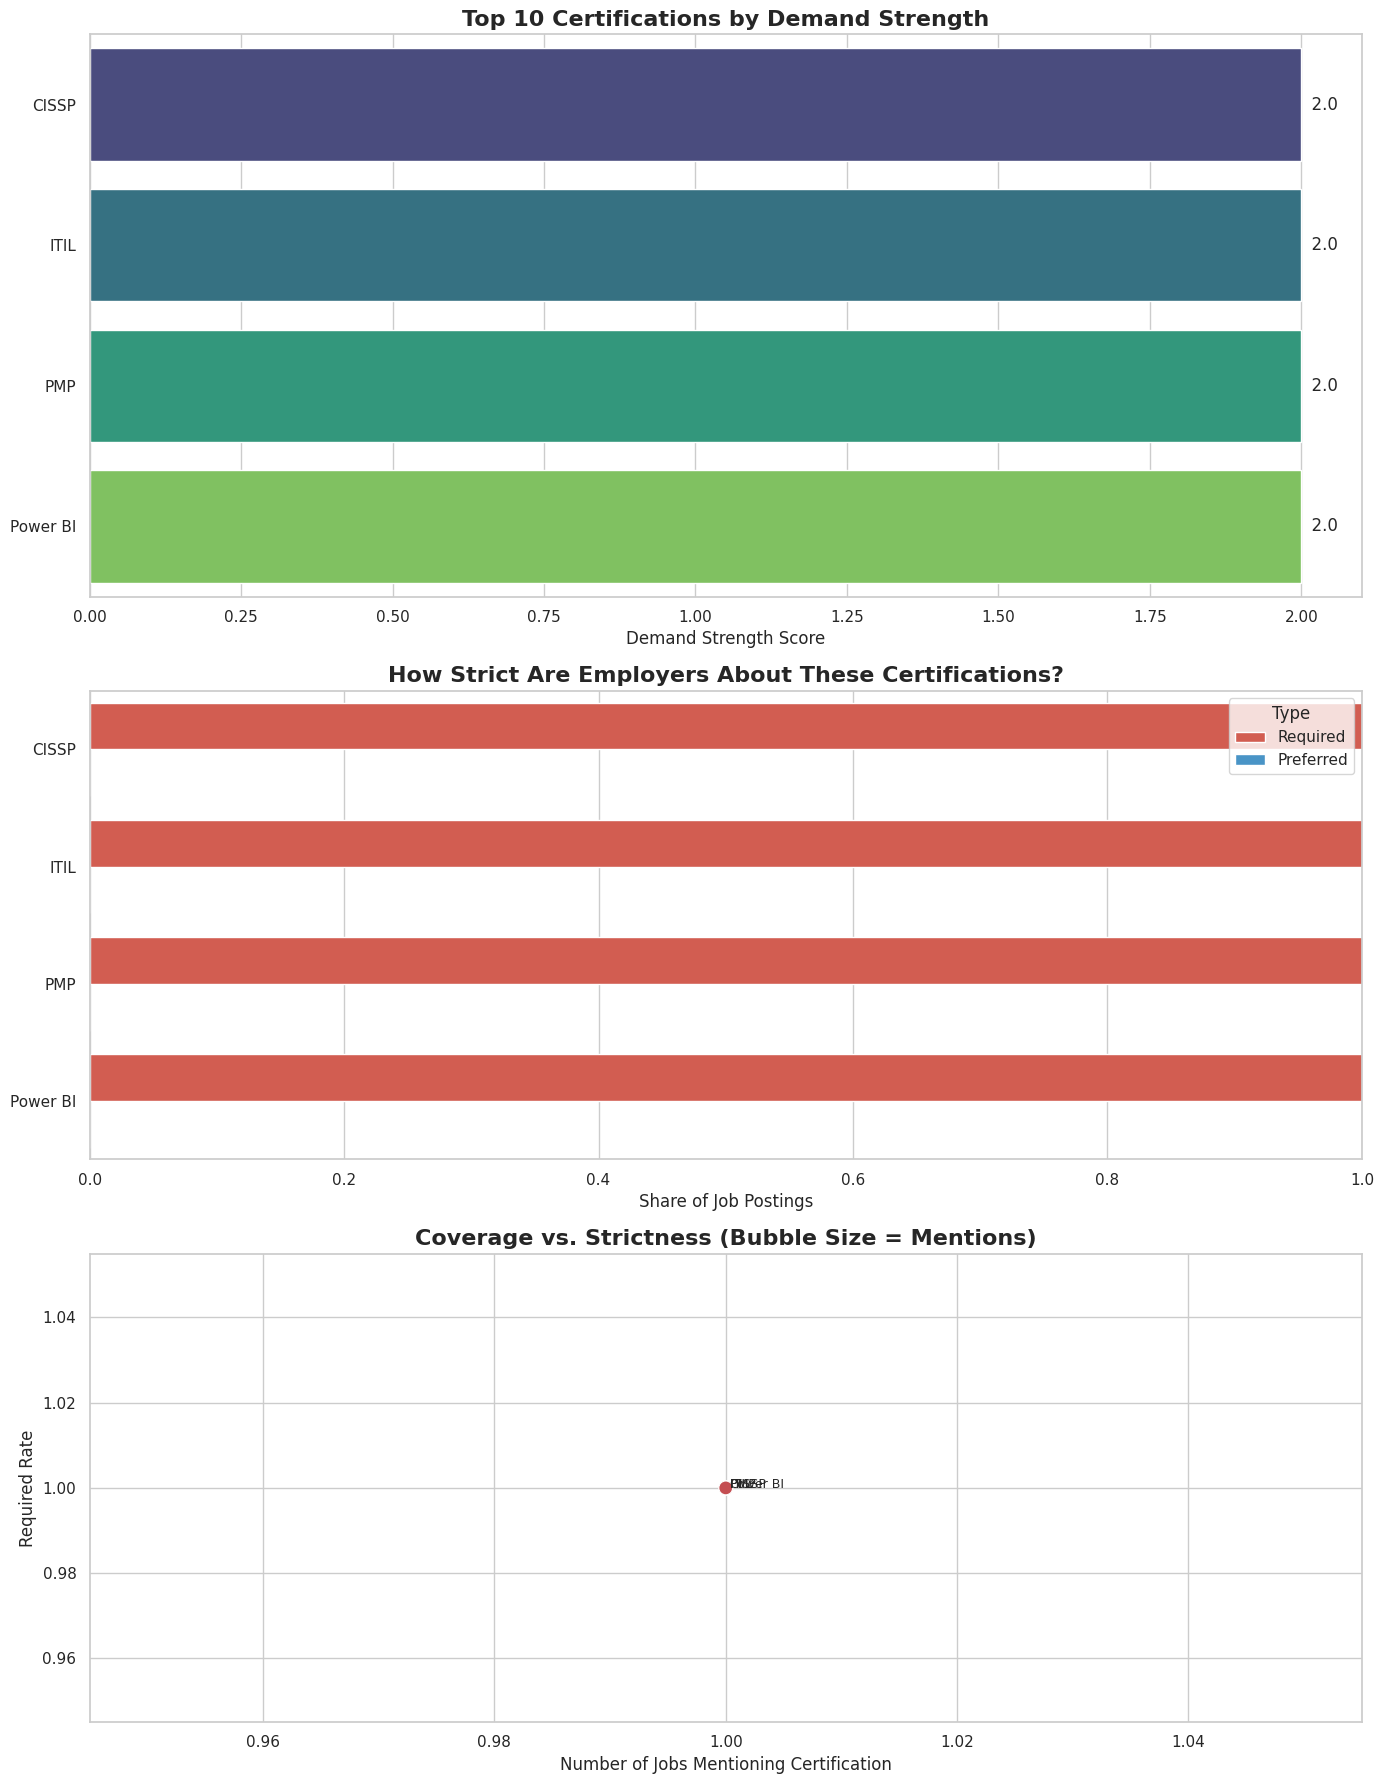

In [165]:
# Refresh analytics data and re-run dashboard
import sqlite3
import pandas as pd

# Re-fetch the data to include the new records
with sqlite3.connect(DB_NAME) as conn:
    df_analytics = pd.read_sql_query(QUERY_ANALYTICS, conn)

# Filter for records that actually have certifications before aggregating
demand = (
    df_analytics
    .dropna(subset=['certification'])
    .groupby("certification")
    .agg(
        mentions=("job_id", "count"),
        jobs_covered=("job_id", "nunique"),
        required_count=("requirement_level", lambda x: (x == "required").sum()),
        preferred_count=("requirement_level", lambda x: (x == "preferred").sum())
    )
    .reset_index()
)

if not demand.empty:
    demand["required_rate"] = demand["required_count"] / demand["mentions"]
    demand["preferred_rate"] = demand["preferred_count"] / demand["mentions"]
    demand["demand_score"] = demand["mentions"] * (1 + demand["required_rate"])
    demand = demand.sort_values("demand_score", ascending=False)

    generate_dashboard(demand, top_n=10)
else:
    print("No certification records found to display in the dashboard.")
    print("Current Analytics DataFrame Shape:", df_analytics.shape)
    display(df_analytics.head())